In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
DATA_PATH = Path('..', 'Dataset', 'pre-processed', 'final_preprocessed_good_data.csv')
BAD_DATA_PATH = Path('..','Dataset', 'pre-processed', '402_faulty', 'processed_402_R_faulty.csv')
DATA_PATH.exists()
BAD_DATA_PATH.exists()

True

In [5]:
#Reading both the Datasets using pandas

good_df = pd.read_csv(DATA_PATH)
bad_df = pd.read_csv(BAD_DATA_PATH)

/tmp/ipykernel_272232/1723078287.py:3: DtypeWarning: Columns (0: CH3 Resistance Break, 1: CH4 Resistance Break, 2: CH3 Bounce Break, 3: CH4 Bounce Break, 4: CH1 Resistance Break, 5: CH2 Resistance Break, 6: CH1 Bounce Break, 7: CH2 Bounce Break) have mixed types. Specify dtype option on import or set low_memory=False.
  good_df = pd.read_csv(DATA_PATH)


In [6]:
good_df.head()

,Coil Current C1 (A),Coil Current C2 (A),Coil Current C3 (A),Coil Current C4 (A),Coil Current C5 (A),Coil Current C6 (A),Contact Travel T1 (mm),Contact Travel T2 (mm),Contact Travel T3 (mm),Contact Travel T4 (mm),...,CH3 Resistance Break,CH4 Resistance Break,CH3 Bounce Break,CH4 Bounce Break,CH1 Resistance Break,CH2 Resistance Break,CH1 Bounce Break,CH2 Bounce Break,phase,breaker_id
0,0.000,0.000,0.000,0.029,0.0,0.0,0.0,0.0,0.0,0.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"R,Y",402
1,0.000,0.000,0.000,0.037,0.0,0.0,0.0,0.0,0.0,-0.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"R,Y",402
2,0.000,0.000,0.000,0.051,0.0,0.0,0.0,0.0,0.0,-0.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"R,Y",402
3,0.029,0.044,0.037,0.029,0.0,0.0,0.0,0.0,0.0,0.14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"R,Y",402
4,0.066,0.073,0.066,0.051,0.0,0.0,0.0,0.0,0.0,-0.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"R,Y",402


In [7]:
bad_df.head()

,Coil Current C1 (A),Coil Current C2 (A),Coil Current C3 (A),Coil Current C4 (A),Coil Current C5 (A),Coil Current C6 (A),Contact Travel T1 (mm),Contact Travel T2 (mm),Contact Travel T3 (mm),Contact Travel T4 (mm),...,DCRM Current CH5 in Amp,CH5 Close-Velocity (m/s),CH5 Open-Velocity (m/s),CH5 Test Run,DCRM Res CH6 in uOhm,DCRM Current CH6 in Amp,CH6 Close-Velocity (m/s),CH6 Open-Velocity (m/s),CH6 Test Run,phase
0,0.015,0.029,0.015,0.029,0.0,0.0,0,0,0,0.10,...,0,0,0.12,TR4,368.25,0,0,0.12,TR4,R
1,0.007,0.022,0.000,0.037,0.0,0.0,0,0,0,-0.06,...,0,0,0.12,TR4,379.98,0,0,0.12,TR4,R
2,0.051,0.007,0.000,0.066,0.0,0.0,0,0,0,0.02,...,0,0,0.12,TR4,378.02,0,0,0.12,TR4,R
3,0.161,0.029,0.000,0.051,0.0,0.0,0,0,0,0.10,...,0,0,0.12,TR4,393.65,0,0,0.12,TR4,R
4,0.286,0.022,0.015,0.029,0.0,0.0,0,0,0,0.18,...,0,0,0.12,TR4,393.65,0,0,0.12,TR4,R


Checking which columns in both of the datsets need encoding

In [8]:
for col in good_df.select_dtypes(include=['object']).columns:
    good_df[col] = LabelEncoder().fit_transform(good_df[col].astype(str))
    print(f"Encoded column: {col}")

Encoded column: CH1 Test Run
Encoded column: CH2 Test Run
Encoded column: CH3 Test Run
Encoded column: CH4 Test Run
Encoded column: CH5 Test Run
Encoded column: CH6 Test Run
Encoded column: CH3 Resistance Break
Encoded column: CH4 Resistance Break
Encoded column: CH3 Bounce Break
Encoded column: CH4 Bounce Break
Encoded column: CH1 Resistance Break
Encoded column: CH2 Resistance Break
Encoded column: CH1 Bounce Break
Encoded column: CH2 Bounce Break
Encoded column: phase


/tmp/ipykernel_272232/1396465431.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in good_df.select_dtypes(include=['object']).columns:


In [9]:
for col in bad_df.select_dtypes(include=['object']).columns:
    bad_df[col] = LabelEncoder().fit_transform(bad_df[col].astype(str))
    print(f"Encoded column: {col}")

Encoded column: CH1 Test Run
Encoded column: CH2 Test Run
Encoded column: CH3 Test Run
Encoded column: CH3 Resistance Break
Encoded column: CH4 Test Run
Encoded column: CH4 Resistance Break
Encoded column: CH5 Test Run
Encoded column: CH6 Test Run
Encoded column: phase


/tmp/ipykernel_272232/3777508448.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in bad_df.select_dtypes(include=['object']).columns:


Econding the said columns

In [11]:
for col in good_df.select_dtypes(include=['object']).columns:
    good_df[col] = LabelEncoder().fit_transform(good_df[col].astype(str))
    print(f"✅ Encoded: {col}")

In [ ]:
for col in bad_df.select_dtypes(include=['object']).columns:
    bad_df[col] = LabelEncoder().fit_transform(bad_df[col].astype(str))
    print(f"✅ Encoded: {col}")

Checking if the number of columns in both the datasets are same or not

In [47]:
good_df.dtypes.value_counts()

float64    28
int64      24
Name: count, dtype: int64

In [48]:
bad_df.dtypes.value_counts()

int64      26
float64    20
Name: count, dtype: int64

Making sure that only numeric data ever reaches the model


In [49]:
X_good = good_df.select_dtypes(include=[np.number])
X_faulty = bad_df.select_dtypes(include=[np.number])

only keeping the common columns so that there are no errors/discrepancies

In [50]:
common_cols = list(set(X_good.columns) & set(X_faulty.columns))
X_good = X_good[common_cols]
X_faulty = X_faulty[common_cols]



In [51]:
print(f"Good data shape  : {X_good.shape}")
print(f"Faulty data shape: {X_faulty.shape}")
print(f"Features         : {len(common_cols)}")

Good data shape  : (49500, 45)
Faulty data shape: (4500, 45)
Features         : 45


Creating the train, test split for the good columns 

In [52]:
X_train, X_test_good = train_test_split(X_good, test_size=0.2, random_state=42)


In [54]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train)
print("✅ Model trained!")

✅ Model trained!


In [56]:
y_pred_good = model.predict(X_test_good)

# Predict on faulty data → should be anomaly (-1)
y_pred_faulty = model.predict(X_faulty)

# Results
print(f"\nGood data predictions:")
print(f"  Normal  (1) : {(y_pred_good == 1).sum()}")   # should be high
print(f"  Anomaly (-1): {(y_pred_good == -1).sum()}") 


Good data predictions:
  Normal  (1) : 9412
  Anomaly (-1): 488


In [58]:
# Try higher contamination values
for contamination in [0.05, 0.1, 0.15, 0.2, 0.3]:
    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train)
    y_pred_faulty = model.predict(X_faulty)
    detected = (y_pred_faulty == -1).sum()
    print(f"Contamination {contamination:.2f} → Detected: {detected}/{len(X_faulty)} ({detected/len(X_faulty)*100:.1f}%)")

Contamination 0.05 → Detected: 404/4500 (9.0%)
Contamination 0.10 → Detected: 2024/4500 (45.0%)
Contamination 0.15 → Detected: 3273/4500 (72.7%)
Contamination 0.20 → Detected: 3645/4500 (81.0%)
Contamination 0.30 → Detected: 4215/4500 (93.7%)


In [59]:
for contamination in [0.05, 0.1, 0.15, 0.2, 0.3]:
    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train)
    
    y_pred_faulty = model.predict(X_faulty)
    y_pred_good = model.predict(X_test_good)
    
    detected = (y_pred_faulty == -1).sum()
    false_alarms = (y_pred_good == -1).sum()
    
    print(f"Contamination {contamination:.2f} → "
          f"Detected: {detected/len(X_faulty)*100:.1f}% | "
          f"False Alarms: {false_alarms/len(X_test_good)*100:.1f}%")

Contamination 0.05 → Detected: 9.0% | False Alarms: 4.9%
Contamination 0.10 → Detected: 45.0% | False Alarms: 9.6%
Contamination 0.15 → Detected: 72.7% | False Alarms: 14.7%
Contamination 0.20 → Detected: 81.0% | False Alarms: 20.0%
Contamination 0.30 → Detected: 93.7% | False Alarms: 30.3%


In [60]:
for contamination in [0.15, 0.16, 0.17, 0.18, 0.19, 0.20]:
    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train)
    
    y_pred_faulty = model.predict(X_faulty)
    y_pred_good = model.predict(X_test_good)
    
    detected = (y_pred_faulty == -1).sum()
    false_alarms = (y_pred_good == -1).sum()
    
    print(f"Contamination {contamination:.2f} → "
          f"Detected: {detected/len(X_faulty)*100:.1f}% | "
          f"False Alarms: {false_alarms/len(X_test_good)*100:.1f}%")

Contamination 0.15 → Detected: 72.7% | False Alarms: 14.7%
Contamination 0.16 → Detected: 75.3% | False Alarms: 15.8%
Contamination 0.17 → Detected: 77.0% | False Alarms: 16.8%
Contamination 0.18 → Detected: 78.6% | False Alarms: 17.9%
Contamination 0.19 → Detected: 79.7% | False Alarms: 19.0%
Contamination 0.20 → Detected: 81.0% | False Alarms: 20.0%


Chose Contamination 0.18 because it was giving the best results.


In [62]:
final_model = IsolationForest(
    n_estimators=100,
    contamination=0.18,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.18
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [63]:
import joblib

In [65]:
joblib.dump(final_model, 'isolation_forest_final.pkl')
print("✅ Final model saved with contamination=0.18!")

✅ Final model saved with contamination=0.18!


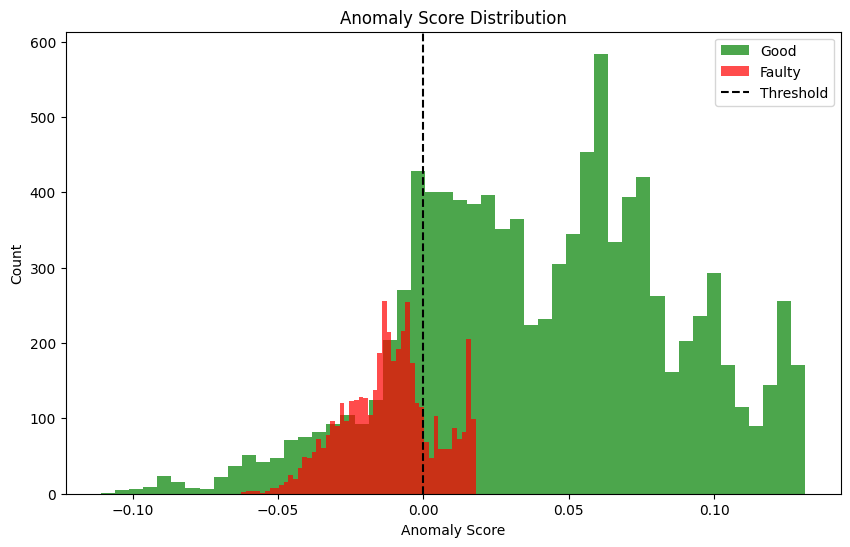

In [66]:
scores_good = final_model.decision_function(X_test_good)
scores_faulty = final_model.decision_function(X_faulty)

plt.figure(figsize=(10, 6))
plt.hist(scores_good, bins=50, alpha=0.7, label='Good', color='green')
plt.hist(scores_faulty, bins=50, alpha=0.7, label='Faulty', color='red')
plt.axvline(x=0, color='black', linestyle='--', label='Threshold')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.title('Anomaly Score Distribution')
plt.legend()
plt.savefig('anomaly_score_distribution.png')
plt.show()

In [68]:
# How well does model detect per phase?
for phase in X_faulty['phase'].unique():
    phase_data = X_faulty[X_faulty['phase'] == phase]
    preds = final_model.predict(phase_data)
    detected = (preds == -1).sum()
    print(f"Phase {phase}: {detected}/{len(phase_data)} detected")

Phase 0: 3535/4500 detected


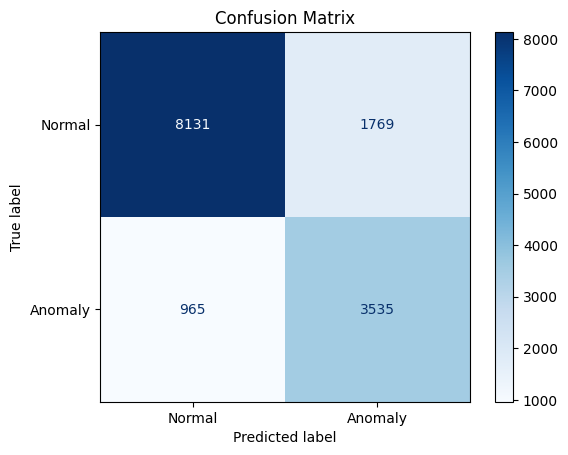

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

y_true = [0] * len(X_test_good) + [1] * len(X_faulty)
y_pred = list((final_model.predict(X_test_good) == -1).astype(int)) + \
         list((final_model.predict(X_faulty) == -1).astype(int))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=['Normal', 'Anomaly'],
    cmap='Blues'
)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

/tmp/ipykernel_16610/73516006.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores_good, scores_faulty], labels=['Good', 'Faulty'])


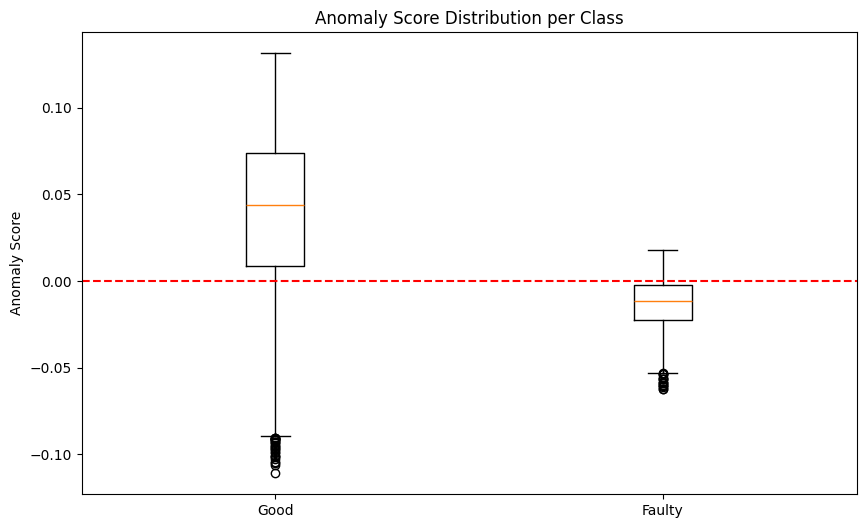

In [70]:
plt.figure(figsize=(10, 6))
plt.boxplot([scores_good, scores_faulty], labels=['Good', 'Faulty'])
plt.axhline(y=0, color='red', linestyle='--', label='Threshold')
plt.ylabel('Anomaly Score')
plt.title('Anomaly Score Distribution per Class')
plt.savefig('boxplot.png')
plt.show()

/home/mushman/Downloads/DCRM_analysis /.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


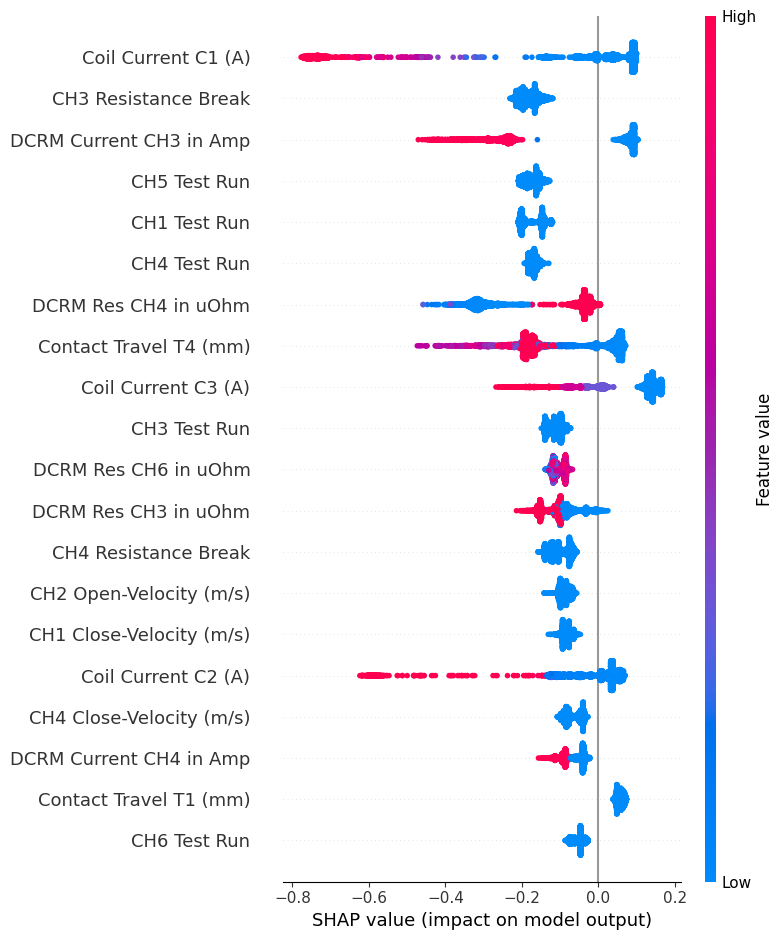

In [72]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_faulty)
shap.summary_plot(shap_values, X_faulty)

In [ ]:
def map_to_component(feature_name):
    feature_lower = feature_name.lower()
    
    if any(x in feature_lower for x in ['coil', 'current']):
        return 'Operating Coil/Mechanism'
    elif any(x in feature_lower for x in ['close-velocity', 'close velocity']):
        return 'Closing Mechanism'
    elif any(x in feature_lower for x in ['open-velocity', 'open velocity']):
        return 'Opening/Spring Mechanism'
    elif any(x in feature_lower for x in ['res', 'resistance']):
        return 'Contact Surface'
    elif any(x in feature_lower for x in ['travel']):
        return 'Mechanical Linkage'
    elif any(x in feature_lower for x in ['bounce', 'bb']):
        return 'Contact Spring'
    elif any(x in feature_lower for x in ['rbreak', 'resistance break']):
        return 'Contact Integrity'
    else:
        return f'Unknown ({feature_name})'